In [1]:
# This will improve in the future so plotting is accessible to all!

import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit
from scipy import stats
from scipy.interpolate import interp1d
import seaborn as sns
from ipywidgets import *
# Apply the default theme
sns.set_theme(palette='dark')

from parameters import *
import save_n_load as sl

I_10KPC = {"LIVERMORE": 2684, "GKVM": 3295, "GARCHING": 882} # Number of expected events at 10 kpc for a 40 kton LArTPC

In [7]:
# Parameters to get the desired curve(s) (feel free to change them to anything you have already computed)
fake_trigger_rate = FAKE_TRIGGER_RATE
burst_time_window = BURST_TIME_WINDOW
distance_to_optimize = DISTANCE_TO_OPTIMIZE
sim_mode = SIM_MODE
adc_mode = ADC_MODE
detector = DETECTOR
classify = CLASSIFY
average_energy = AVERAGE_ENERGY
alpha = ALPHA

sim_parameters = [fake_trigger_rate, burst_time_window, distance_to_optimize, sim_mode, adc_mode, detector, classify, average_energy, alpha]
file_name = None

In [3]:
# Or just specify the filename(s)
sim_parameters = []
file_name = "wahtevs.pcl"

{(3.8580246913580245e-07, 1000000.0, 12, 'xe', 'normal', 'VD', True, 23.0, 5.0): 'efficiency_curve_Z4XCFYHV.pcl'}
Loaded efficiency curve from file efficiency_curve_Z4XCFYHV.pcl


Text(0, 0.5, 'Efficiency')

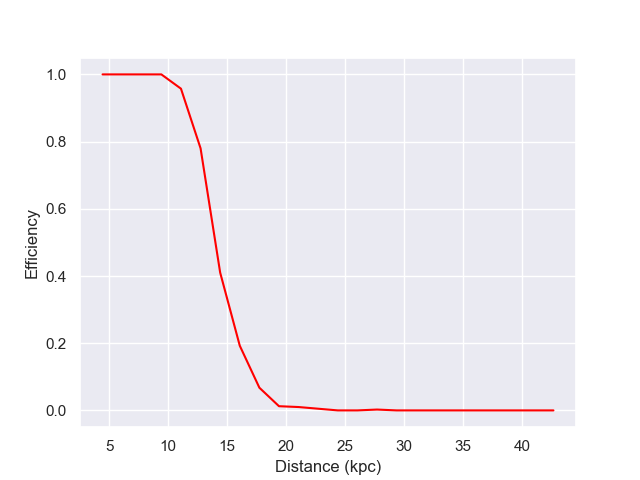

In [8]:
%matplotlib widget
# Load the curves

eff_curve_data, _ = sl.load_efficiency_data(sim_parameters, file_name, data_type="curve")
distances = eff_curve_data[0]
efficiencies = eff_curve_data[1]

# All efficiency curves are calculated with the Livermore event number normalization. This is not a problem, we can normalize to whatever we want now.
# For example:
norm = I_10KPC["GKVM"]
gkvm_distances = np.array(distances) * np.sqrt(norm/I_10KPC["LIVERMORE"])

plt.plot(gkvm_distances, efficiencies, color="red")
plt.xlabel("Distance (kpc)")
plt.ylabel("Efficiency")

## Pinched fluxes
$\phi\left(E_{\nu}\right)=\mathcal{N}\left(\frac{E_{\nu}}{\left\langle E_{\nu}\right\rangle}\right)^{\alpha} \exp \left[-(\alpha+1) \frac{E_{\nu}}{\left\langle E_{\nu}\right\rangle}\right]$

interactive(children=(FloatSlider(value=3.0, description='alpha', max=10.0), FloatSlider(value=10.0, descripti…

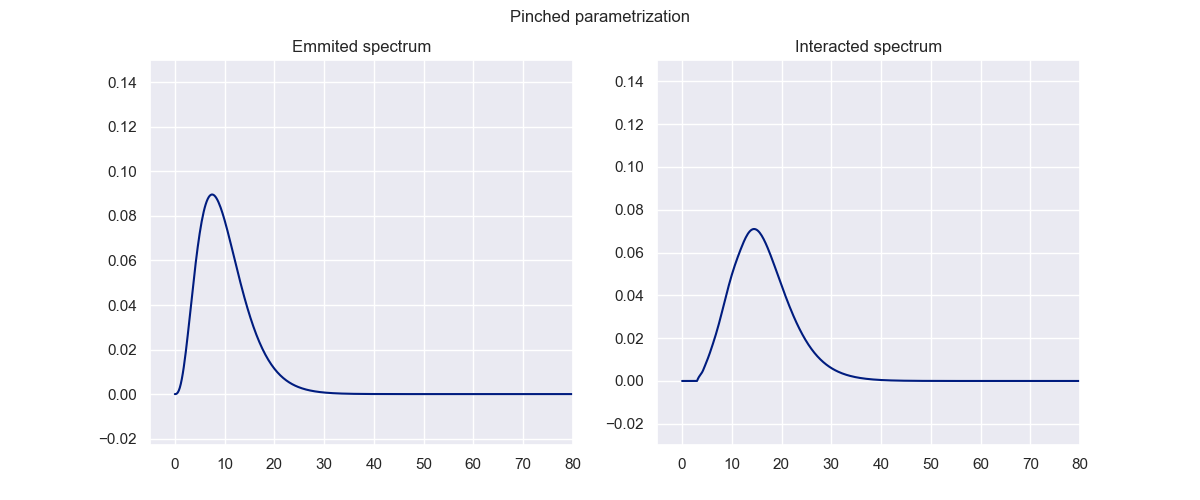

In [9]:
%matplotlib widget
xsec_sg_path = "./aux_pickles/xscns/"
marley_1 = np.genfromtxt(xsec_sg_path + "xs_nue_Ar40.dat", skip_footer=0)
sng = np.genfromtxt(xsec_sg_path + "xs_nue_Ar40_marley2.dat", skip_footer=0)

log_e, xsec = marley_1[:, 0], marley_1[:, 1]
log_e_sg, xsec_sg = sng[:, 0], sng[:, 1]
e = 10**log_e * 1000
e_sg = 10**log_e_sg

def pinched_spectrum(energies, average_e, alpha):
    spectrum = (energies/average_e)**alpha * np.exp(- (alpha + 1) * energies/average_e)
    norm = np.sum(spectrum * np.diff(energies)[0])
    return spectrum/norm

energies_p = np.arange(0, 100, 0.2)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Pinched parametrization")

line_0, = ax[0].plot(energies_p, pinched_spectrum(energies_p, 3, 10))
ax[0].set_ylim(top=0.15)
ax[0].set_xlim(right=80)
ax[0].set_title("Emmited spectrum")

#plt.plot(flux_e, flux_spec/flux_norm)

# --------------------------------------------------------------------------------

xsec_interp = np.interp(energies_p, e, xsec)
interacted_spectrum = pinched_spectrum(energies_p, 3, 10) * xsec_interp
norm = np.sum(interacted_spectrum * np.diff(energies_p)[0])
line_1, = ax[1].plot(energies_p, interacted_spectrum / norm)

ax[1].set_ylim(top=0.15)
ax[1].set_xlim(right=80)
ax[1].set_title("Interacted spectrum")
#ax[1].plot(sg_pinched_energies, sg_pinched_spectrum/sg_pinched_norm, label="GKVM SNOwGLoBES")

def update_2(alpha = 3.0, average_e = 10.0):
    line_0.set_ydata(pinched_spectrum(energies_p, average_e, alpha))
    fig.canvas.draw_idle()

    interacted_spectrum = pinched_spectrum(energies_p, average_e, alpha) * xsec_interp
    norm = np.sum(interacted_spectrum * np.diff(energies_p)[0])
    line_1.set_ydata(interacted_spectrum / norm)
    fig.canvas.draw_idle()
interact(update_2, alpha=(0.0, 10.0, 0.1), average_e=(0.1, 40.0, 0.1));